# LangGraph Components

## 1. State (❤️ Heart of LangGraph)

- Shared memory accessible by all nodes.
- Stores the application's current data.
- Nodes **read** from it and **return updates** to it.
- Defined using `TypedDict`, `dataclass`, or `Pydantic`.
**Flow**
```text
Input State → Node → Updated State → Next Node
```
---
## 2. Nodes
- A node is simply a Python function.
- Performs one specific task (LLM call, tool call, API call, etc.).
- Takes the current state as input.
- Returns a partial state update.

**Flow**
```text
State → Node(Function) → State Update
```
---
## 3. Edges
- Connect one node to another.
- Define the execution flow.
- Unconditional edges always go to the same next node.
**Flow**
```text
START → Search → LLM → END
```
---
## 4. Conditional Edges

- Decide the next node based on the current state.
- Similar to an `if-else` statement.
- Enable branching, retries, loops, and agent decision-making.
**Flow**
```text
           Search
              │
      documents found?
         ┌────┴────┐
        Yes       No
         │         │
        LLM    Search Again
         │         │
         └────┬────┘
              END
```
## 5. Reducers
- Define **how state updates are merged** when multiple nodes update the same key.
- By default, LangGraph **overwrites** the existing value.
- Reducers allow custom merge behavior (e.g., append, sum, merge).
- Commonly used for accumulating messages or list data.
**Without Reducer**
```text
["Hi"] → Update ["Hello"] → ["Hello"]
```
**With Reducer (Append)**
```text
["Hi"] → Update ["Hello"] → ["Hi", "Hello"]
```

## Build a basic chatbot with Langgraph(Graph API)

In [6]:
%load_ext autoreload
%autoreload 2

In [7]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END 
from langgraph.graph.message import add_messages # add_messages is a reducer

In [8]:
class State(TypedDict):
    messages:Annotated[list,add_messages]
graph_builder=StateGraph(State)

In [9]:
graph_builder

In [10]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [6]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="llama-3.1-8b-instant")

In [7]:
 ## Node functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]} 

In [8]:
graph_builder=StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot",chatbot)
## Adding edges 
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## compile the graph
graph=graph_builder.compile()

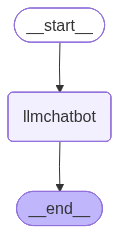

In [9]:
from IPython.display import Image,display
try:
    display(Image(graph.get_graph().draw_mermaid_png())) 
except Exception:
    pass
    

In [76]:
response=graph.invoke({"messages":"Hello"})

In [77]:
response["messages"][-1].content

'Hello. Is there something I can help you with or would you like to chat?'

In [78]:
for event in graph.stream({"messages":"Hi,How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm doing well, thank you for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm here to help answer any questions or provide information you might need. How can I assist you today?


## CHATBOT WITH TOOL

In [79]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the n

In [10]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)

In [11]:
## Custom function
def multiply(a:int,b:int)->int:
    """Multiply a and b
    
    Args:
        a (int): first int
        b (int): second int
        
    Returns:
        int: output int
    """
    return a*b


In [12]:
tools=[tool,multiply]

In [13]:
llm_with_tool=llm.bind_tools(tools)

In [14]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x7cf768f06d80>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7cf768e6b4a0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimi

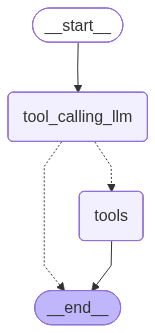

In [15]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}
## Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add edge
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # if the latest result from llm is a tool call ->tools condition routes to tools(node)
    # else: tools condition routes to END
    tools_condition
)

builder.add_edge("tools",END)

## Compile the graph
graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [85]:
result=graph.invoke({"messages":"What is the recent AI news?"})

In [87]:
result["messages"][-1].content

"{'error': ValueError('Error 400: When time_range is set, start_date or end_date cannot be set')}"

In [88]:
result=graph.invoke({"messages":"What is 2 multiplied by 3?"})
result["messages"][-1].content   ## here also tool call happening  

'6'

## Failure case : When a user request needs the usage of multiple tools calls,model calls one tool and exits with output

In [89]:
result=graph.invoke({"messages":"What is 2 multiplied by 3 and give one recent AI news?"})
result["messages"][-1].content 

'6'

In [90]:
result

{'messages': [HumanMessage(content='What is 2 multiplied by 3 and give one recent AI news?', additional_kwargs={}, response_metadata={}, id='2736b9fe-02dc-44b5-8b24-c863a50396f9'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'jbatw3pnv', 'function': {'arguments': '{"a":2,"b":3}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 39, 'prompt_tokens': 1760, 'total_tokens': 1799, 'completion_time': 0.073911188, 'completion_tokens_details': None, 'prompt_time': 0.129684712, 'prompt_tokens_details': None, 'queue_time': 0.058404877, 'total_time': 0.2035959}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f34d9-b59e-7431-a965-773b9177db47-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'jbatw3pnv', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metad

 # ReAct Agent : Required for efficient communication between agents
 ![React Agent Architecture](assets/image1.png)
 - ACT
 - OBSERVE
 - REASON


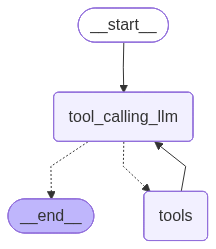

In [16]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}
## Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add edge
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # if the latest result from llm is a tool call ->tools condition routes to tools(node)
    # else: tools condition routes to END
    tools_condition
)

builder.add_edge("tools","tool_calling_llm")

## Compile the graph
graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [92]:
result=graph.invoke({"messages":"Give me recent AI news and then multiply 2 and 3"})
result["messages"][-1].content 

"The function 'multiply' returned the product of 2 and 3 as 6."

In [93]:
result

{'messages': [HumanMessage(content='Give me recent AI news and then multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='597ba80a-6eee-4fc8-afb3-602b868649df'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'f4eqscjpd', 'function': {'arguments': '{"query":"recent AI news","time_range":"week","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}, {'id': 'yw1fzf0b5', 'function': {'arguments': '{"a":2,"b":3}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 1758, 'total_tokens': 1807, 'completion_time': 0.070268847, 'completion_tokens_details': None, 'prompt_time': 0.119211758, 'prompt_tokens_details': None, 'queue_time': 0.056194973, 'total_time': 0.189480605}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f34d9-f56e-7d63-9b3

# Adding Memory in Agentic Graph

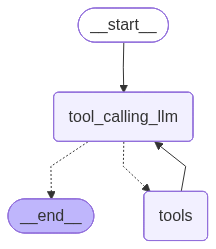

In [17]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory=MemorySaver()

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}
## Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add edge
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # if the latest result from llm is a tool call ->tools condition routes to tools(node)
    # else: tools condition routes to END
    tools_condition
)

builder.add_edge("tools","tool_calling_llm")

## Compile the graph
graph=builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [105]:
## We need to create a thread id for holding a session memory for a thread
from langchain_core.messages import HumanMessage
config={"configurable":{"thread_id":"1"}}
response=graph.invoke({"messages":[HumanMessage(content="Hello, my name is Arun")]},config=config)
response

{'messages': [HumanMessage(content='Hello, my name is Arun', additional_kwargs={}, response_metadata={}, id='3f887310-faa1-46f7-9490-a9e97001f640'),
  AIMessage(content='Nice to meet you, Arun. How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 1752, 'total_tokens': 1768, 'completion_time': 0.02065528, 'completion_tokens_details': None, 'prompt_time': 0.111286031, 'prompt_tokens_details': None, 'queue_time': 0.049156949, 'total_time': 0.131941311}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f34e1-e322-7d40-a58e-29591b129543-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1752, 'output_tokens': 16, 'total_tokens': 1768})]}

In [106]:
response["messages"][-1].content

'Nice to meet you, Arun. How can I assist you today?'

In [107]:
response=graph.invoke({"messages":"Hey,do you remeber my name?"},config=config)
response

{'messages': [HumanMessage(content='Hello, my name is Arun', additional_kwargs={}, response_metadata={}, id='3f887310-faa1-46f7-9490-a9e97001f640'),
  AIMessage(content='Nice to meet you, Arun. How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 1752, 'total_tokens': 1768, 'completion_time': 0.02065528, 'completion_tokens_details': None, 'prompt_time': 0.111286031, 'prompt_tokens_details': None, 'queue_time': 0.049156949, 'total_time': 0.131941311}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f34e1-e322-7d40-a58e-29591b129543-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1752, 'output_tokens': 16, 'total_tokens': 1768}),
  HumanMessage(content='Hey,do you remeber my name?', additional_kwargs={}, response_metadata={}, id='0b73a365-667d-4ea

# Streaming 

In [18]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

In [19]:
def superbot(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

# Streaming

Methods: `.stream()` and `astream()`

* These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

* **values** : This streams the full state of the graph after each node is called.
* **updates** : This streams updates to the state of the graph after each node is called.

In [29]:
config={"configurable":{"thread_id":"3"}}
for chunk in graph.stream({"messages":"Hi my name is Arun and I want today's news about cricket"},config,stream_mode="updates"):
    print(chunk)


{'tool_calling_llm': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'snja05vtk', 'function': {'arguments': '{"query":"cricket news today","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 4299, 'total_tokens': 4324, 'completion_time': 0.033790197, 'completion_tokens_details': None, 'prompt_time': 0.328448817, 'prompt_tokens_details': None, 'queue_time': 0.064955478, 'total_time': 0.362239014}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f66c3-160b-7042-af14-4ad67582e36b-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'cricket news today', 'topic': 'news'}, 'id': 'snja05vtk', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 4299, 'output_tokens': 25, 'total_tokens': 4324})]}

### the above result is not as expected cause the model is not capable of formulating the messages in a way so that it remembers the previous conversation exactly

In [33]:
config={"configurable":{"thread_id":"5"}}
async for event in graph.astream_events({"messages":"Hi my name is Arun and I want today's news about cricket"},config,version="v2"):
    print(chunk)


{'tool_calling_llm': {'messages': [AIMessage(content="Here are the latest news articles about cricket:\n\n* India crushes England by 270 runs to win historic first women’s test at Lord’s\n* Former BCCI CEO Rahul Johri Joins Board of Flash Sports & Media Holdings, Inc.\n\nLet me know if you'd like to know more about these articles or if you'd like to search for something else!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 74, 'prompt_tokens': 5081, 'total_tokens': 5155, 'completion_time': 0.113712945, 'completion_tokens_details': None, 'prompt_time': 0.377218943, 'prompt_tokens_details': None, 'queue_time': 0.06347156, 'total_time': 0.490931888}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f66c3-1fe0-7cf0-882e-2db2e8b62f39-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 5081, 'output

# Human in the LOOP

In [30]:
import os
from langchain_groq import ChatGroq
llm=ChatGroq(model="llama-3.1-8b-instant")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x779942c49490>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x779942fa8e30>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [31]:
from typing import Annotated
from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode,tools_condition

from langgraph.types import Command, interrupt

class State(TypedDict):
    messages: Annotated[list,add_messages]

graph_builder=StateGraph(State)


@tool
def human_assistance(query:str)-> str:
    """ Request assistance from human """
    human_response=interrupt({"query":query})
    return human_response["data"]

tool=TavilySearch(max_results=2)
tools=[tool,human_assistance]
llm_with_tools=llm.bind_tools(tools)

def chatbot(state:State):
    message=llm_with_tools.invoke(state["messages"])
    """ because we will be interrupting during tool execution, we disable parrallel tool calling to avoid repeating any tool invocations when we resume """
    return {"messages":[message]}

graph_builder.add_node("chatbot",chatbot)
tool_node=ToolNode(tools=tools)
graph_builder.add_node("tools",tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)

graph_builder.add_edge("tools","chatbot")
graph_builder.add_edge(START,"chatbot")


In [32]:
memory=MemorySaver()
graph=graph_builder.compile(checkpointer=memory)

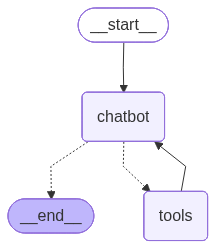

In [33]:
from IPython.display import Image,display 
display(Image(graph.get_graph().draw_mermaid_png()))

In [36]:
user_input = "I need some expert assistance for building an AI agent. Could you request assistance for me?"
config = {"configurable": {"thread_id": "1"}}

events = graph.stream(
    {"messages": user_input},
    config,
    stream_mode="values",
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert assistance for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (gjh5y3rmr)
 Call ID: gjh5y3rmr
  Args:
    query: expert assistance for building AI agent using LangGraph
================================== Ai Message ==================================
Tool Calls:
  human_assistance (gjh5y3rmr)
 Call ID: gjh5y3rmr
  Args:
    query: expert assistance for building AI agent using LangGraph


In [37]:
human_response = (
    "We, the experts are here to help! We'd recommend you check out LangGraph to build your agent."
    " It's much more reliable and extensible than simple autonomous agents."
)

human_command = Command(resume={"data": human_response})

events = graph.stream(human_command, config, stream_mode="values")
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (gjh5y3rmr)
 Call ID: gjh5y3rmr
  Args:
    query: expert assistance for building AI agent using LangGraph
================================= Tool Message =================================
Name: human_assistance

We, the experts are here to help! We'd recommend you check out LangGraph to build your agent. It's much more reliable and extensible than simple autonomous agents.
================================== Ai Message ==================================
Tool Calls:
  tavily_search (41r2b1py1)
 Call ID: 41r2b1py1
  Args:
    query: tips for building AI agent using LangGraph
    search_depth: advanced
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "tips for building AI agent using LangGraph", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://medium.com/python